### 손글씨 MNIST

In [2]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


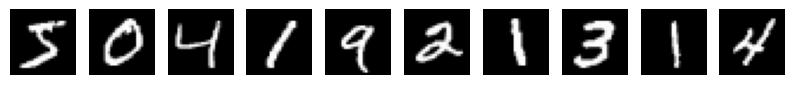

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
  axs[i].imshow(train_input[i], cmap='gray')
  axs[i].axis('off')
  plt.show()

#### 인공신경망 확인


In [ ]:
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target))

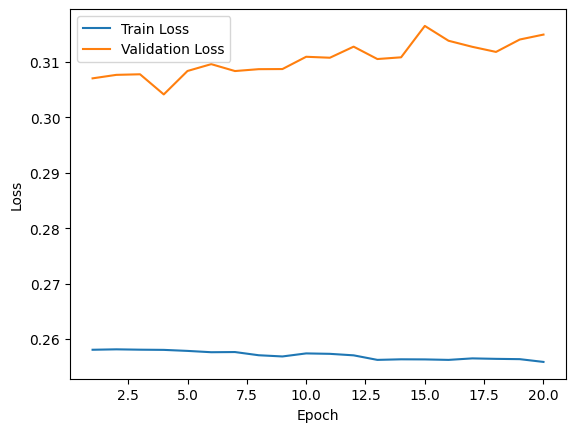

In [28]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

# 2. 에포크 축 만들기
epochs = range(1, len(train_loss) + 1)

# 3. 학습 곡선 시각화
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show() # ephoch =3~4에서 Validation Loss가 증가하는 것을 확인, Ephoch를 5로 선정

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# 데이터 정규화 및 2차 행렬 만들기
train_scaled = train_input/ 255.0
train_scaled = train_scaled.reshape(-1, 28*28)
train_scaled.shape

(60000, 784)

In [8]:
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [10]:
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [11]:
from tensorflow.keras.layers import Input
model = keras.Sequential()
model.add(Input(shape=(28*28,)))
model.add(keras.layers.Dense(10, activation='softmax')) # 이진분류만 SIGMOID, 나머지는 softmax 사용

In [12]:
model.compile(
    loss = "sparse_categorical_crossentropy", # 객관식이구나
    metrics = ["accuracy"]
)

In [29]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9368 - loss: 0.2553
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9363 - loss: 0.2556
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9364 - loss: 0.2555
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9370 - loss: 0.2557
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9374 - loss: 0.2560


In [30]:
# 검증 데이터로 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.3166


[0.31656914949417114, 0.9241666793823242]

In [34]:
# Ephoch에 따른 Scores 확인(train, valid, test)
print(model.evaluate(train_scaled, train_target))
print(model.evaluate(val_scaled, val_target))

# test_input도 train_scaled와 동일하게 전처리합니다.
test_scaled = test_input / 255.0
test_scaled = test_scaled.reshape(-1, 28*28)

print(model.evaluate(test_scaled, test_target))

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 994us/step - accuracy: 0.9383 - loss: 0.2493
[0.24929334223270416, 0.9382500052452087]
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9242 - loss: 0.3166  
[0.31656914949417114, 0.9241666793823242]
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9266 - loss: 0.3009
[0.3009282052516937, 0.9265999794006348]


In [35]:
 import pandas as pd

# 1. 테스트 데이터 전처리는 반복문 밖에서 1번만 수행합니다.
test_scaled = test_input / 255.0
test_scaled = test_scaled.reshape(-1, 28*28)

# 결과를 담을 빈 리스트 준비
epochs_list = []
train_scores = []
valid_scores = []
test_scores = []

print("학습 및 평가 시작...")

# 2. 1부터 10까지 반복 (에포크 1~10)
for epoch in range(1, 11):

    # 모델을 1 에포크씩 학습시킵니다. (이전 학습 상태가 유지됨)
    # verbose=0으로 설정하여 fit 자체의 길고 복잡한 출력 로그를 숨깁니다.
    model.fit(train_scaled, train_target, epochs=1, verbose=0)

    # 각 데이터셋에 대해 평가를 진행합니다.
    # evaluate는 일반적으로 [loss, accuracy] 리스트를 반환하므로,
    # 정확도(인덱스 1)만 추출하기 위해 [1]을 붙입니다.
    # (만약 손실(loss)만 뽑힌다면 [1]을 [0]으로 지우거나 수정해야 합니다.)
    train_res = model.evaluate(train_scaled, train_target, verbose=0)[1]
    valid_res = model.evaluate(val_scaled, val_target, verbose=0)[1]
    test_res  = model.evaluate(test_scaled, test_target, verbose=0)[1]

    # 리스트에 현재 에포크의 기록을 추가
    epochs_list.append(epoch)
    train_scores.append(train_res)
    valid_scores.append(valid_res)
    test_scores.append(test_res)

    print(f"Epoch {epoch}/10 완료")

# 3. 수집된 리스트를 판다스 DataFrame으로 변환
df_scores = pd.DataFrame({
    'Epoch': epochs_list,
    'Train Score': train_scores,
    'Valid Score': valid_scores,
    'Test Score': test_scores
})

# 인덱스를 에포크 번호로 설정하여 깔끔하게 보기
df_scores = df_scores.set_index('Epoch')

# 4. 보기 좋게 소수점 4자리까지 포맷팅하여 출력
print("\n[ 에포크별 정확도(Accuracy) 결과 ]")
print(df_scores.round(4))

학습 및 평가 시작...
Epoch 1/10 완료
Epoch 2/10 완료
Epoch 3/10 완료
Epoch 4/10 완료
Epoch 5/10 완료
Epoch 6/10 완료
Epoch 7/10 완료
Epoch 8/10 완료
Epoch 9/10 완료
Epoch 10/10 완료

[ 에포크별 정확도(Accuracy) 결과 ]
       Train Score  Valid Score  Test Score
Epoch                                      
1           0.9371       0.9232      0.9233
2           0.9374       0.9217      0.9253
3           0.9387       0.9228      0.9260
4           0.9379       0.9229      0.9252
5           0.9386       0.9212      0.9260
6           0.9371       0.9225      0.9244
7           0.9377       0.9223      0.9247
8           0.9384       0.9234      0.9246
9           0.9390       0.9225      0.9253
10          0.9380       0.9229      0.9252
